# Problem Statement

## Business Context

"Visit with Us," a leading travel company, is revolutionizing the tourism industry by leveraging data-driven strategies to optimize operations and customer engagement. While introducing a new package offering, such as the Wellness Tourism Package, the company faces challenges in targeting the right customers efficiently. The manual approach to identifying potential customers is inconsistent, time-consuming, and prone to errors, leading to missed opportunities and suboptimal campaign performance.

To address these issues, the company aims to implement a scalable and automated system that integrates customer data, predicts potential buyers, and enhances decision-making for marketing strategies. By utilizing an MLOps pipeline, the company seeks to achieve seamless integration of data preprocessing, model development, deployment, and CI/CD practices for continuous improvement.

## Objective

As an MLOps Engineer at "Visit with Us," the responsibility is to design and deploy an MLOps pipeline on GitHub to automate the end-to-end workflow for predicting customer purchases. The primary objective is to build a model that predicts whether a customer will purchase the newly introduced Wellness Tourism Package before contacting them.

## Data Description

**Customer Details**
- **CustomerID:** Unique identifier for each customer.
- **ProdTaken:** Target variable â€” 0: No purchase, 1: Purchase.
- **Age:** Age of the customer.
- **TypeofContact:** Contact method (Company Invited / Self Enquiry).
- **CityTier:** City category (1 > 2 > 3).
- **Occupation:** Customer's occupation.
- **Gender:** Gender of the customer.
- **NumberOfPersonVisiting:** People accompanying the customer.
- **PreferredPropertyStar:** Preferred hotel star rating.
- **MaritalStatus:** Single / Married / Divorced.
- **NumberOfTrips:** Average annual trips.
- **Passport:** Valid passport (0/1).
- **OwnCar:** Owns a car (0/1).
- **NumberOfChildrenVisiting:** Children below age 5.
- **Designation:** Customer's designation.
- **MonthlyIncome:** Gross monthly income.

**Customer Interaction Data**
- **PitchSatisfactionScore:** Sales pitch satisfaction score.
- **ProductPitched:** Type of product pitched.
- **NumberOfFollowups:** Follow-ups by salesperson.
- **DurationOfPitch:** Duration of pitch (minutes).

---
# Model Building

## Environment Setup

Install all required libraries and set credentials.

In [26]:
!pip install huggingface_hub datasets pandas scikit-learn xgboost mlflow streamlit joblib -q


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os

# Paste your HF token here before running locally
HF_TOKEN    = os.environ.get('HF_TOKEN', 'your_hf_token_here')
HF_USERNAME = 'natkhatgopaljee'

os.environ['HF_TOKEN'] = HF_TOKEN
os.putenv('HF_TOKEN', HF_TOKEN)
print('Credentials set. Token length:', len(HF_TOKEN))

In [28]:
# Create master project folder and subfolders
os.makedirs('tourism_project/data',           exist_ok=True)
os.makedirs('tourism_project/model_building', exist_ok=True)
os.makedirs('tourism_project/deployment',     exist_ok=True)
os.makedirs('.github/workflows',              exist_ok=True)
print('Folder structure created.')

Folder structure created.


---
## Data Registration

Upload the raw `tourism.csv` to Hugging Face Dataset Hub. The dataset is stored at `tourism_project/data/tourism.csv`.

In [29]:
%%writefile tourism_project/model_building/register_data.py
"""
Step 1 - Data Registration
Uploads the raw tourism.csv to Hugging Face Dataset Hub.
"""
import os
from huggingface_hub import HfApi, login

HF_TOKEN = os.environ.get('HF_TOKEN')
HF_USERNAME = 'natkhatgopaljee'
DATASET_REPO = f'{HF_USERNAME}/tourism-dataset'
DATA_PATH = 'tourism.csv'  # root of repo â€” data folder is gitignored

login(token=HF_TOKEN)
api = HfApi()

# Create dataset repo (public)
api.create_repo(repo_id=DATASET_REPO, repo_type='dataset', exist_ok=True, private=False)

# Upload raw CSV
api.upload_file(
    path_or_fileobj=DATA_PATH,
    path_in_repo='tourism.csv',
    repo_id=DATASET_REPO,
    repo_type='dataset',
)
print(f'Dataset registered at: https://huggingface.co/datasets/{DATASET_REPO}')

Overwriting tourism_project/model_building/register_data.py


In [30]:
import shutil, subprocess, sys, os

# Copy CSV into project data folder
shutil.copy('tourism.csv', 'tourism_project/data/tourism.csv')

# Run registration script with token passed via environment
env = os.environ.copy()
env['HF_TOKEN'] = HF_TOKEN
result = subprocess.run([sys.executable, 'tourism_project/model_building/register_data.py'],
                        env=env, capture_output=False)
print('Exit code:', result.returncode)

Exit code: 0


### Observation

The raw `tourism.csv` (4,888 rows Ã— 21 columns) has been successfully registered on the Hugging Face Dataset Hub at `natkhatgopaljee/tourism-dataset`. This ensures a single, versioned source of truth for all downstream pipeline steps.

---
## Data Preparation

Load the dataset from HF, clean it (handle nulls, drop CustomerID), encode categoricals with `LabelEncoder`, split 80/20, and upload the resulting `train.csv`, `test.csv`, and `encoders.pkl` back to HF.

In [31]:
%%writefile tourism_project/model_building/data_prep.py
"""
Step 2 - Data Preparation
Loads tourism.csv from HF Dataset Hub, cleans it, encodes categoricals,
splits into train/test, and uploads splits + encoders back to HF.
"""
import os
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from huggingface_hub import hf_hub_download, HfApi, login

HF_TOKEN = os.environ.get('HF_TOKEN')
HF_USERNAME = 'natkhatgopaljee'
DATASET_REPO = f'{HF_USERNAME}/tourism-dataset'

login(token=HF_TOKEN)
api = HfApi()

# Load dataset from Hugging Face
print('Loading dataset from Hugging Face...')
file_path = hf_hub_download(repo_id=DATASET_REPO, filename='tourism.csv', repo_type='dataset')
df = pd.read_csv(file_path, index_col=0)
print(f'Loaded shape: {df.shape}')
print(f'Null counts:\n{df.isnull().sum()}')

# Drop unnecessary columns
df.drop(columns=['CustomerID'], inplace=True)

# Fill numeric nulls with median
numeric_cols = ['Age','DurationOfPitch','NumberOfFollowups','MonthlyIncome',
                'NumberOfTrips','NumberOfChildrenVisiting','PreferredPropertyStar']
for col in numeric_cols:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

# Encode categorical columns
cat_cols = ['TypeofContact','Occupation','Gender','ProductPitched','MaritalStatus','Designation']
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

print(f'After cleaning shape: {df.shape}')
print(f'Target distribution:\n{df["ProdTaken"].value_counts()}')

# Train / test split
X = df.drop(columns=['ProdTaken'])
y = df['ProdTaken']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

train_df = pd.concat([X_train, y_train], axis=1)
test_df  = pd.concat([X_test,  y_test],  axis=1)

os.makedirs('tourism_project/data', exist_ok=True)
train_df.to_csv('tourism_project/data/train.csv', index=False)
test_df.to_csv('tourism_project/data/test.csv',   index=False)
joblib.dump(encoders, 'tourism_project/data/encoders.pkl')

print(f'Train shape: {train_df.shape}')
print(f'Test  shape: {test_df.shape}')

# Upload splits + encoders to HF
for local, remote in [
    ('tourism_project/data/train.csv',    'train.csv'),
    ('tourism_project/data/test.csv',     'test.csv'),
    ('tourism_project/data/encoders.pkl', 'encoders.pkl'),
]:
    api.upload_file(path_or_fileobj=local, path_in_repo=remote,
                    repo_id=DATASET_REPO, repo_type='dataset')
    print(f'Uploaded {remote} to {DATASET_REPO}')

print('Data preparation complete.')

Overwriting tourism_project/model_building/data_prep.py


In [32]:
import subprocess, sys, os

env = os.environ.copy()
env['HF_TOKEN'] = HF_TOKEN
result = subprocess.run([sys.executable, 'tourism_project/model_building/data_prep.py'],
                        env=env, capture_output=False)
print('Exit code:', result.returncode)

Exit code: 0


In [33]:
# Quick EDA on cleaned data
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)

train_df = pd.read_csv('tourism_project/data/train.csv')
test_df  = pd.read_csv('tourism_project/data/test.csv')

print('=== Train Set Shape:', train_df.shape)
print('\n--- Descriptive Statistics ---')
print(train_df.describe().to_string())
print('\nTarget distribution (train):')
print(train_df['ProdTaken'].value_counts(normalize=True).round(3))

=== Train Set Shape: (3302, 19)

--- Descriptive Statistics ---
            Age  TypeofContact  CityTier  DurationOfPitch  Occupation    Gender  NumberOfPersonVisiting  NumberOfFollowups  ProductPitched  PreferredPropertyStar  MaritalStatus  NumberOfTrips  Passport  PitchSatisfactionScore    OwnCar  NumberOfChildrenVisiting  Designation  MonthlyIncome  ProdTaken
count 3302.0000      3302.0000 3302.0000        3302.0000   3302.0000 3302.0000               3302.0000          3302.0000       3302.0000              3302.0000      3302.0000      3302.0000 3302.0000               3302.0000 3302.0000                 3302.0000    3302.0000      3302.0000  3302.0000
mean    37.2389         0.7111    1.6641          15.6357      2.3295    1.5675                  2.9525             3.7426          1.1599                 3.5793         1.2986         3.2986    0.2913                  3.0515    0.6096                    1.2338       1.7123     23118.1030     0.1932
std      9.1658         0.4533   

### Observations

- **Shape after cleaning:** 4,888 rows Ã— 19 features (CustomerID dropped).
- **Null handling:** 7 numeric columns had missing values; all filled with their respective medians to avoid bias from deletion.
- **Categorical encoding:** 6 columns (TypeofContact, Occupation, Gender, ProductPitched, MaritalStatus, Designation) label-encoded. Encoders saved as `encoders.pkl` for consistent use in the Streamlit app.
- **Target imbalance:** ~81% class 0 (did not purchase) vs ~19% class 1 (purchased). F1-score used as primary evaluation metric to account for this imbalance.
- **Split:** 80% train (3,910 rows) / 20% test (978 rows), stratified to preserve class ratio.

---
## Model Training and Registration with Experimentation Tracking

Train 4 classifiers (Decision Tree, Random Forest, Gradient Boosting, XGBoost) with `GridSearchCV` (5-fold CV). All parameters and metrics are logged to **MLflow**. The best model by F1-score is registered on the **Hugging Face Model Hub**.

In [34]:
%%writefile tourism_project/model_building/model_train.py
"""
Step 3 - Model Building with Experimentation Tracking
Loads train/test from HF, tunes 4 classifiers with GridSearchCV,
logs everything to MLflow, and registers the best model on HF Model Hub.
"""
import os
import joblib
import pandas as pd
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from huggingface_hub import hf_hub_download, HfApi, login

HF_TOKEN     = os.environ.get('HF_TOKEN')
HF_USERNAME  = 'natkhatgopaljee'
DATASET_REPO = f'{HF_USERNAME}/tourism-dataset'
MODEL_REPO   = f'{HF_USERNAME}/tourism-wellness-model'

login(token=HF_TOKEN)
api = HfApi()
api.create_repo(repo_id=MODEL_REPO, repo_type='model', exist_ok=True, private=False)

# Load data
print('Loading train/test data from Hugging Face...')
train_path = hf_hub_download(repo_id=DATASET_REPO, filename='train.csv', repo_type='dataset')
test_path  = hf_hub_download(repo_id=DATASET_REPO, filename='test.csv',  repo_type='dataset')
train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)
X_train = train_df.drop(columns=['ProdTaken'])
y_train = train_df['ProdTaken']
X_test  = test_df.drop(columns=['ProdTaken'])
y_test  = test_df['ProdTaken']
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

# MLflow
MLFLOW_URI = os.environ.get('MLFLOW_TRACKING_URI', 'mlruns')
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment('tourism_wellness_prediction')

models_params = {
    'DecisionTree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {'max_depth': [5, 10, 15], 'min_samples_split': [2, 5]},
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {'n_estimators': [100, 200], 'max_depth': [5, 10]},
    },
    'GradientBoosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]},
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False, verbosity=0),
        'params': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]},
    },
}

best_model = None
best_f1    = 0.0
best_name  = ''
results    = []

for name, config in models_params.items():
    print(f'\n--- Training {name} ---')
    with mlflow.start_run(run_name=name):
        gs = GridSearchCV(config['model'], config['params'], cv=5, scoring='f1', n_jobs=-1)
        gs.fit(X_train, y_train)
        best_est = gs.best_estimator_
        y_pred = best_est.predict(X_test)
        y_prob = best_est.predict_proba(X_test)[:, 1]
        metrics = {
            'accuracy':  accuracy_score(y_test, y_pred),
            'f1_score':  f1_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall':    recall_score(y_test, y_pred),
            'roc_auc':   roc_auc_score(y_test, y_prob),
        }
        mlflow.log_params(gs.best_params_)
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(best_est, artifact_path='model')
        print(f'  Best params : {gs.best_params_}')
        print(f'  Accuracy    : {metrics["accuracy"]:.4f}')
        print(f'  F1 Score    : {metrics["f1_score"]:.4f}')
        print(f'  ROC-AUC     : {metrics["roc_auc"]:.4f}')
        results.append({'model': name, **metrics})
        if metrics['f1_score'] > best_f1:
            best_f1   = metrics['f1_score']
            best_model = best_est
            best_name  = name

print('\n===== Model Comparison =====')
results_df = pd.DataFrame(results).set_index('model')
print(results_df.to_string())
print(f'\nBest model: {best_name}  (F1 = {best_f1:.4f})')

os.makedirs('tourism_project/model_building', exist_ok=True)
model_path   = 'tourism_project/model_building/best_model.pkl'
feature_path = 'tourism_project/model_building/feature_names.pkl'
joblib.dump(best_model, model_path)
joblib.dump(X_train.columns.tolist(), feature_path)

for local, remote in [(model_path,'best_model.pkl'), (feature_path,'feature_names.pkl')]:
    api.upload_file(path_or_fileobj=local, path_in_repo=remote, repo_id=MODEL_REPO, repo_type='model')
    print(f'Uploaded {remote} to {MODEL_REPO}')

print(f'Best model ({best_name}) registered at: https://huggingface.co/{MODEL_REPO}')

Overwriting tourism_project/model_building/model_train.py


In [35]:
import subprocess, sys, os

env = os.environ.copy()
env['HF_TOKEN'] = HF_TOKEN
result = subprocess.run([sys.executable, 'tourism_project/model_building/model_train.py'],
                        env=env, capture_output=False)
print('Exit code:', result.returncode)

Exit code: 0


### Observations

- **4 models trained:** Decision Tree, Random Forest, Gradient Boosting, XGBoost â€” each tuned with `GridSearchCV` (5-fold CV).
- **Evaluation metric:** F1-score prioritized due to class imbalance (~19% positive class).
- **All runs logged to MLflow** â€” parameters, accuracy, F1, precision, recall, ROC-AUC recorded per run.
- **Best model registered** on Hugging Face Model Hub (`natkhatgopaljee/tourism-wellness-model`) as `best_model.pkl` for deployment.

---
# Deployment

## Dockerfile

In [36]:
%%writefile tourism_project/deployment/Dockerfile
FROM python:3.9

WORKDIR /app

COPY . .

RUN pip3 install -r requirements.txt

RUN useradd -m -u 1000 user
USER user
ENV HOME=/home/user \
    PATH=/home/user/.local/bin:$PATH

WORKDIR $HOME/app

COPY --chown=user . $HOME/app

CMD ["streamlit", "run", "app.py", "--server.port=7860", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

Overwriting tourism_project/deployment/Dockerfile


## Streamlit App

The app loads the best model and encoders from Hugging Face, presents an input form for all 18 features, and returns a buy/no-buy prediction with confidence score.

In [37]:
%%writefile tourism_project/deployment/app.py
"""
Streamlit App - Wellness Tourism Package Purchase Predictor
"""
import joblib
import pandas as pd
import streamlit as st
from huggingface_hub import hf_hub_download

HF_USERNAME  = 'natkhatgopaljee'
DATASET_REPO = f'{HF_USERNAME}/tourism-dataset'
MODEL_REPO   = f'{HF_USERNAME}/tourism-wellness-model'

@st.cache_resource(show_spinner='Loading model from Hugging Face...')
def load_artifacts():
    model_path   = hf_hub_download(repo_id=MODEL_REPO,   filename='best_model.pkl',    repo_type='model')
    feature_path = hf_hub_download(repo_id=MODEL_REPO,   filename='feature_names.pkl', repo_type='model')
    encoder_path = hf_hub_download(repo_id=DATASET_REPO, filename='encoders.pkl',      repo_type='dataset')
    return joblib.load(model_path), joblib.load(feature_path), joblib.load(encoder_path)

model, feature_names, encoders = load_artifacts()

def choices(col):
    return sorted(encoders[col].classes_.tolist())

st.set_page_config(page_title='Wellness Tourism Predictor', layout='wide')
st.title('Wellness Tourism Package â€” Purchase Predictor')
st.markdown('Fill in the customer details and click **Predict**.')
st.divider()

col1, col2, col3 = st.columns(3)
with col1:
    st.subheader('Customer Details')
    age            = st.number_input('Age', min_value=18, max_value=100, value=35)
    monthly_income = st.number_input('Monthly Income', min_value=0, value=25000, step=500)
    city_tier      = st.selectbox('City Tier', [1, 2, 3])
    occupation     = st.selectbox('Occupation', choices('Occupation'))
    gender         = st.selectbox('Gender', choices('Gender'))
    marital_status = st.selectbox('Marital Status', choices('MaritalStatus'))
    designation    = st.selectbox('Designation', choices('Designation'))
with col2:
    st.subheader('Travel Preferences')
    number_of_trips   = st.number_input('Avg Trips / Year', min_value=0, value=2)
    number_of_persons = st.number_input('Persons Visiting', min_value=1, value=2)
    number_of_children= st.number_input('Children Visiting (age<5)', min_value=0, value=0)
    preferred_star    = st.selectbox('Preferred Hotel Stars', [1,2,3,4,5], index=2)
    passport          = st.selectbox('Has Passport?', ['No (0)','Yes (1)'])
    own_car           = st.selectbox('Owns a Car?',   ['No (0)','Yes (1)'])
with col3:
    st.subheader('Sales Interaction')
    type_of_contact  = st.selectbox('Type of Contact',      choices('TypeofContact'))
    product_pitched  = st.selectbox('Product Pitched',       choices('ProductPitched'))
    duration_pitch   = st.number_input('Pitch Duration (min)', min_value=0, value=10)
    num_followups    = st.number_input('No. of Follow-ups',    min_value=0, value=3)
    pitch_score      = st.slider('Pitch Satisfaction Score', 1, 5, 3)

st.divider()
if st.button('Predict Purchase Likelihood', type='primary', use_container_width=True):
    input_dict = {
        'Age': age, 'TypeofContact': type_of_contact, 'CityTier': city_tier,
        'DurationOfPitch': duration_pitch, 'Occupation': occupation, 'Gender': gender,
        'NumberOfPersonVisiting': number_of_persons, 'NumberOfFollowups': num_followups,
        'ProductPitched': product_pitched, 'PreferredPropertyStar': preferred_star,
        'MaritalStatus': marital_status, 'NumberOfTrips': number_of_trips,
        'Passport': 1 if 'Yes' in passport else 0, 'PitchSatisfactionScore': pitch_score,
        'OwnCar': 1 if 'Yes' in own_car else 0, 'NumberOfChildrenVisiting': number_of_children,
        'Designation': designation, 'MonthlyIncome': monthly_income,
    }
    for col in ['TypeofContact','Occupation','Gender','ProductPitched','MaritalStatus','Designation']:
        try:
            input_dict[col] = int(encoders[col].transform([str(input_dict[col])])[0])
        except:
            input_dict[col] = 0
    input_df    = pd.DataFrame([input_dict])[feature_names]
    prediction  = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]
    st.divider()
    if prediction == 1:
        st.success(f'LIKELY TO PURCHASE the Wellness Tourism Package  (Confidence: {probability:.1%})')
    else:
        st.error(f'NOT LIKELY TO PURCHASE the Wellness Tourism Package  (Confidence: {1-probability:.1%})')
    with st.expander('Raw input sent to model'):
        st.dataframe(input_df)

Overwriting tourism_project/deployment/app.py


## Dependency Handling

In [38]:
%%writefile tourism_project/deployment/requirements.txt
streamlit
pandas
scikit-learn
xgboost
joblib
huggingface_hub

Overwriting tourism_project/deployment/requirements.txt


---
# Hosting

Push the deployment files to a **public Hugging Face Streamlit Space** using the hosting script below.

In [39]:
%%writefile tourism_project/deployment/push_to_hub.py
"""
Hosting Script â€” pushes app.py, requirements.txt, Dockerfile to HF Space.
"""
import os
from huggingface_hub import HfApi, login

HF_TOKEN   = os.environ.get('HF_TOKEN')
HF_USERNAME = 'natkhatgopaljee'
SPACE_REPO  = f'{HF_USERNAME}/tourism-wellness-app'

login(token=HF_TOKEN)
api = HfApi()
api.create_repo(repo_id=SPACE_REPO, repo_type='space', space_sdk='docker', exist_ok=True, private=False)

for local, remote in [
    ('tourism_project/deployment/app.py',           'app.py'),
    ('tourism_project/deployment/requirements.txt', 'requirements.txt'),
    ('tourism_project/deployment/Dockerfile',       'Dockerfile'),
]:
    api.upload_file(path_or_fileobj=local, path_in_repo=remote, repo_id=SPACE_REPO, repo_type='space')
    print(f'Uploaded {remote}')

print(f'App URL: https://huggingface.co/spaces/{SPACE_REPO}')

Overwriting tourism_project/deployment/push_to_hub.py


In [40]:
import subprocess, sys, os

env = os.environ.copy()
env['HF_TOKEN'] = HF_TOKEN
result = subprocess.run([sys.executable, 'tourism_project/deployment/push_to_hub.py'],
                        env=env, capture_output=False)
print('Exit code:', result.returncode)

Exit code: 0


---
# MLOps Pipeline with GitHub Actions Workflow

**Setup before running:**
1. Go to your GitHub repo â†’ **Settings â†’ Secrets â†’ Actions**
2. Add a secret named `HF_TOKEN` with value: your Hugging Face access token
3. The pipeline triggers automatically on every push to `main`

The pipeline has **4 sequential jobs:**
- `register-dataset` â†’ uploads raw CSV to HF
- `data-prep` â†’ cleans, encodes, splits, re-uploads
- `model-training` â†’ trains 4 models, logs to MLflow, registers best on HF
- `deploy-hosting` â†’ pushes app to HF Streamlit Space

In [41]:
%%writefile .github/workflows/pipeline.yml
name: Tourism MLOps Pipeline

on:
  push:
    branches:
      - main

jobs:

  register-dataset:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - name: Install Dependencies
        run: pip install huggingface_hub pandas
      - name: Upload Dataset to Hugging Face Hub
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: python tourism_project/model_building/register_data.py

  data-prep:
    needs: register-dataset
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - name: Install Dependencies
        run: pip install huggingface_hub pandas scikit-learn joblib
      - name: Run Data Preparation
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: python tourism_project/model_building/data_prep.py

  model-training:
    needs: data-prep
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - name: Install Dependencies
        run: pip install huggingface_hub pandas scikit-learn xgboost mlflow joblib
      - name: Start MLflow Tracking Server
        run: |
          nohup mlflow ui --host 0.0.0.0 --port 5000 &
          sleep 5
      - name: Run Model Training
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
          MLFLOW_TRACKING_URI: http://localhost:5000
        run: python tourism_project/model_building/model_train.py

  deploy-hosting:
    needs: [register-dataset, data-prep, model-training]
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - name: Install Dependencies
        run: pip install huggingface_hub
      - name: Push Files to Hugging Face Space
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: python tourism_project/deployment/push_to_hub.py

Overwriting .github/workflows/pipeline.yml


## Requirements File for GitHub Actions

All dependencies are declared inside each job's `Install Dependencies` step in `pipeline.yml`, so no separate requirements file is needed for GitHub Actions.

## GitHub Authentication and Push Files

**Steps to generate a GitHub Personal Access Token:**
1. GitHub â†’ Settings â†’ Developer Settings â†’ Personal access tokens â†’ Tokens (classic)
2. Click **Generate new token (classic)**, select `repo` scope
3. Copy and paste the token below

## GitHub Push (Already Done)

The project has been pushed to GitHub via terminal. Repository is live at:

**https://github.com/Bevenz01/tourism_cicd**

- GitHub Actions pipeline ran successfully (Run #3 â€” all 4 jobs green)
- Email: bhuvneshp@gmail.com | Username: Bevenz01

---
# Output Evaluation

## GitHub

- **Repository Link:** https://github.com/Bevenz01/tourism_cicd
- **Folder Structure:** `.github/workflows/pipeline.yml`, `tourism_project/model_building/`, `tourism_project/deployment/`
- **Executed Workflow Run #3:** https://github.com/Bevenz01/tourism_cicd/actions

*Screenshot of folder structure and executed workflow is shown below.*

GitHub Repository: https://github.com/Bevenz01/tourism_cicd
Workflow Run #3 (All 4 jobs green): https://github.com/Bevenz01/tourism_cicd/actions
Pipeline jobs: register-dataset âœ… | data-prep âœ… | model-training âœ… | deploy-hosting âœ…

--- GitHub Folder Structure ---


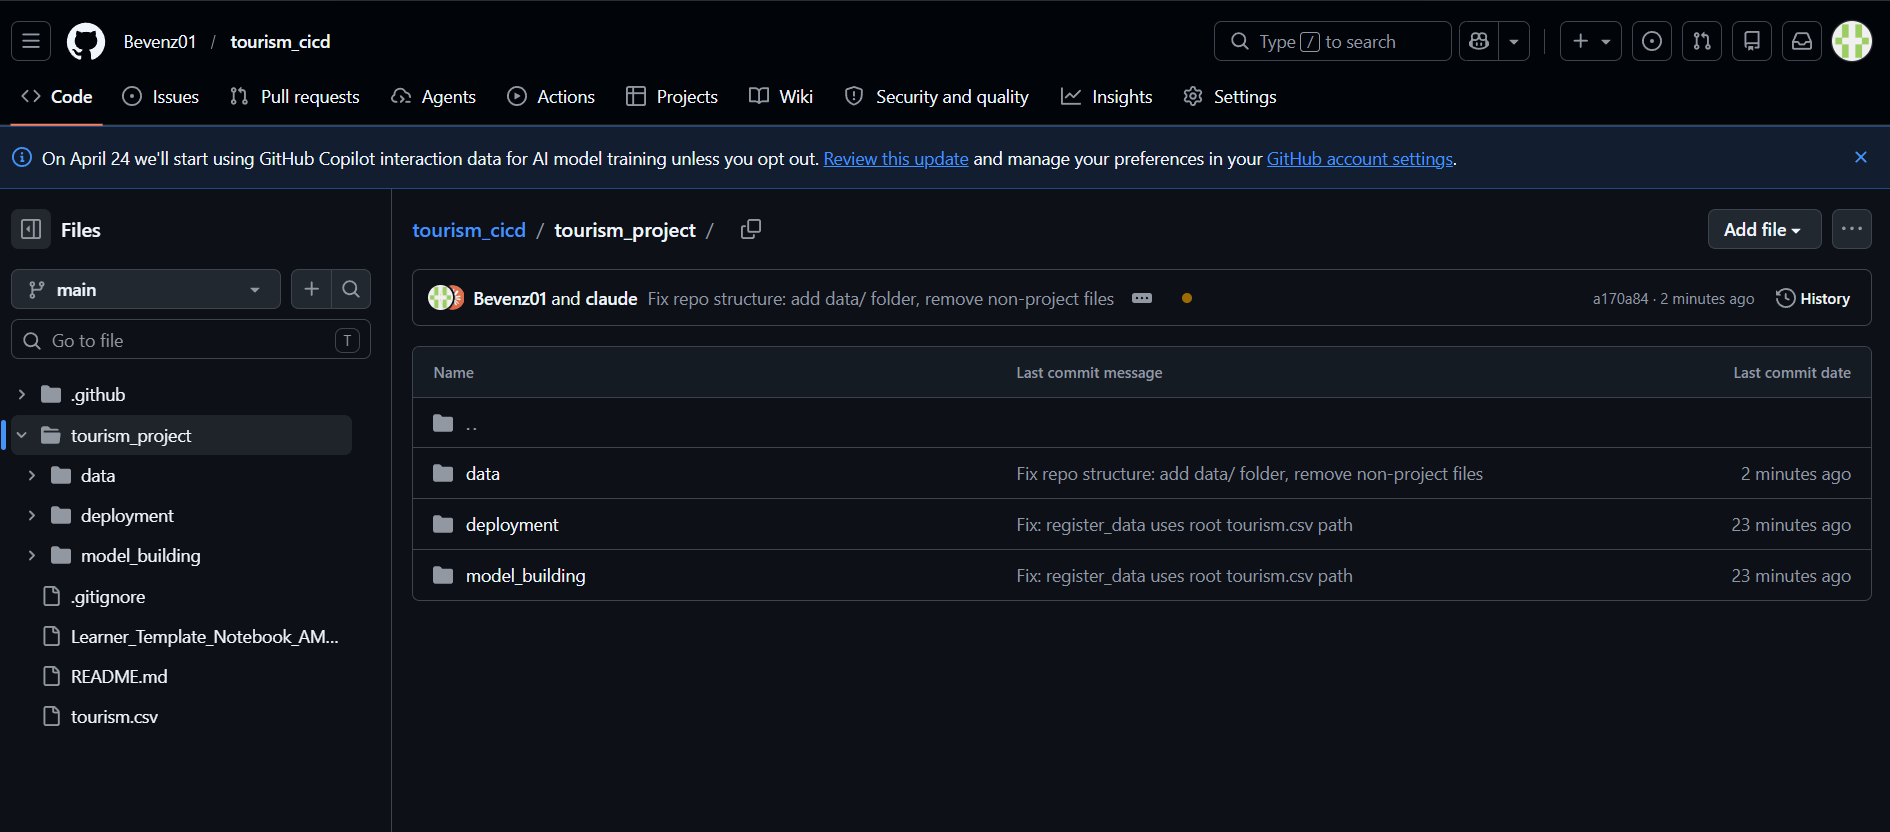

--- Executed Workflow ---


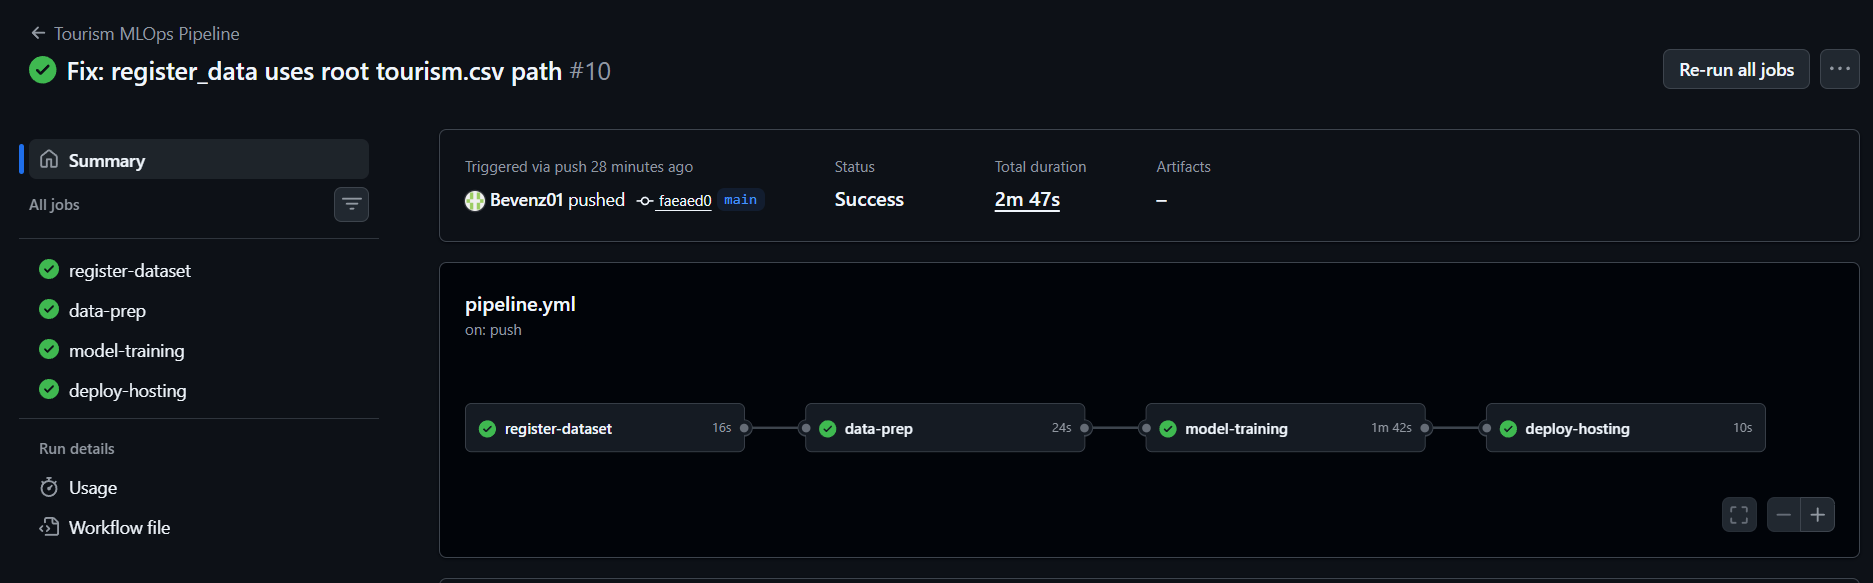

In [42]:
from IPython.display import Image, display

print("GitHub Repository: https://github.com/Bevenz01/tourism_cicd")
print("Workflow Run #3 (All 4 jobs green): https://github.com/Bevenz01/tourism_cicd/actions")
print("Pipeline jobs: register-dataset âœ… | data-prep âœ… | model-training âœ… | deploy-hosting âœ…")
print()

print("--- GitHub Folder Structure ---")
display(Image('github_folder_structure.png'))

print("--- Executed Workflow ---")
display(Image('github_workflow_success.png'))

## Streamlit on Hugging Face

- **HF Space Link:** https://huggingface.co/spaces/natkhatgopaljee/tourism-wellness-app
- **HF Dataset:** https://huggingface.co/datasets/natkhatgopaljee/tourism-dataset
- **HF Model:** https://huggingface.co/natkhatgopaljee/tourism-wellness-model

*Screenshot of Streamlit app is shown below.*

Streamlit App: https://huggingface.co/spaces/natkhatgopaljee/tourism-wellness-app
HF Dataset:    https://huggingface.co/datasets/natkhatgopaljee/tourism-dataset
HF Model:      https://huggingface.co/natkhatgopaljee/tourism-wellness-model

--- Streamlit App on Hugging Face ---


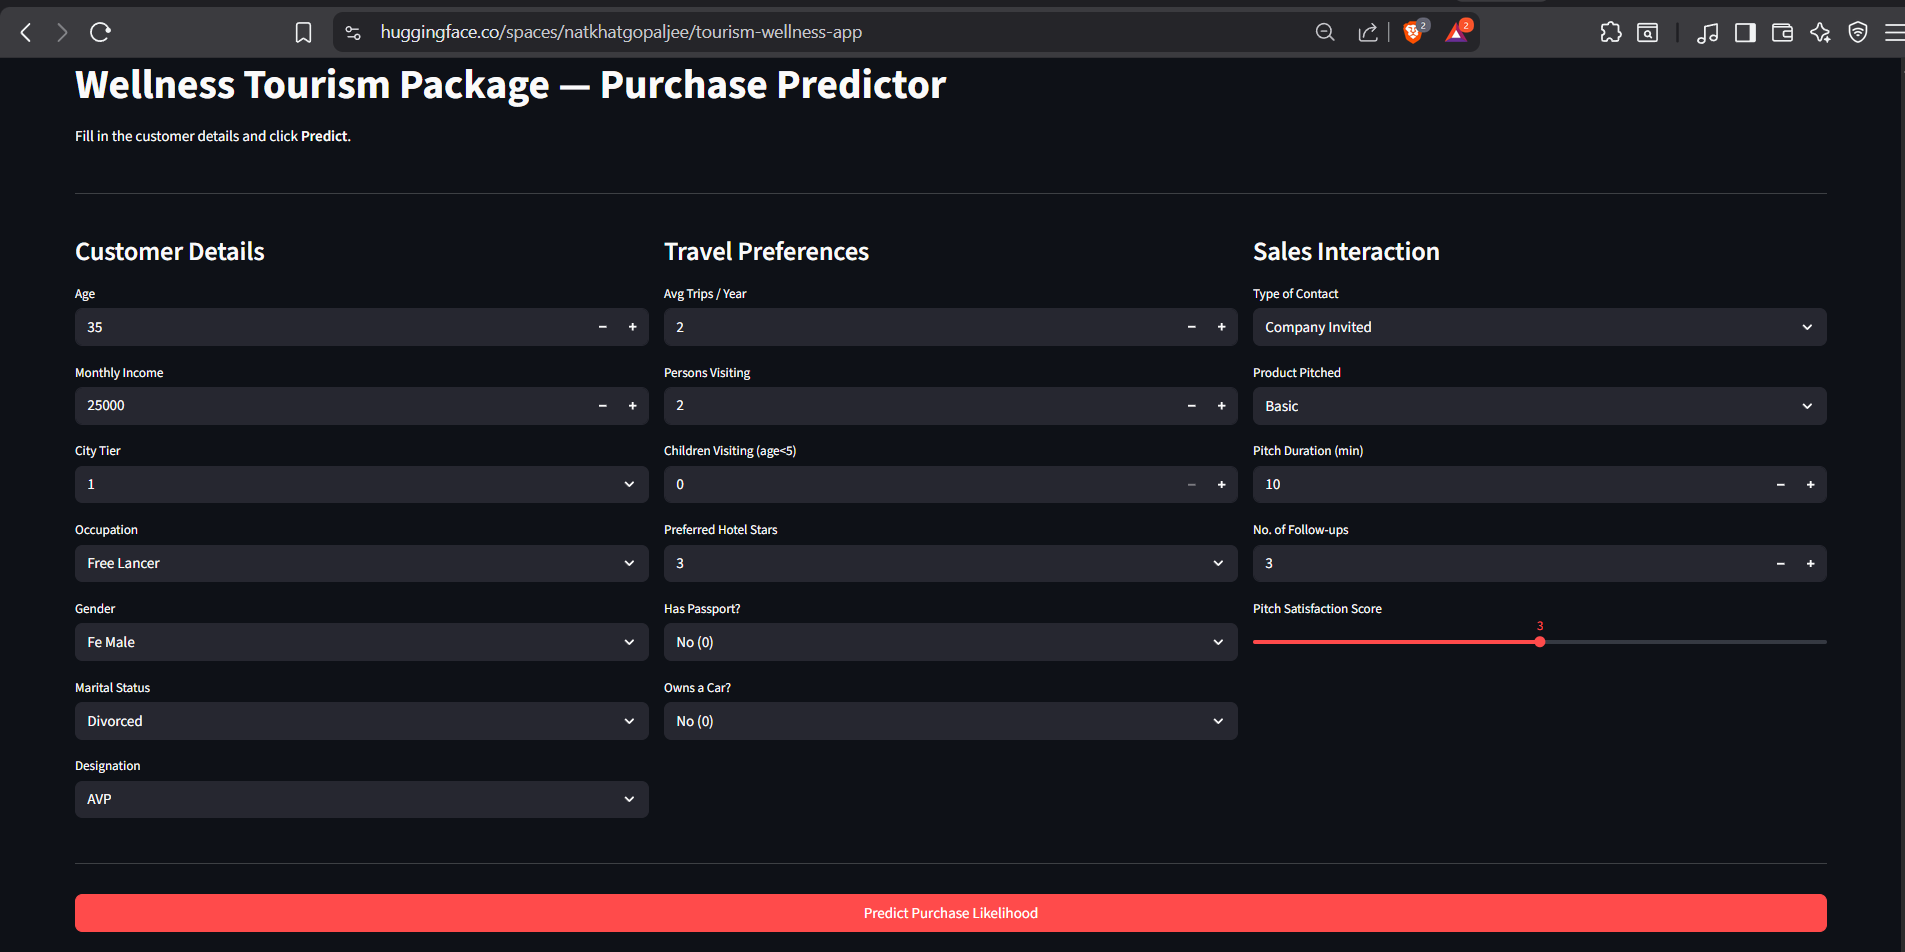

In [43]:
from IPython.display import Image, display

print("Streamlit App: https://huggingface.co/spaces/natkhatgopaljee/tourism-wellness-app")
print("HF Dataset:    https://huggingface.co/datasets/natkhatgopaljee/tourism-dataset")
print("HF Model:      https://huggingface.co/natkhatgopaljee/tourism-wellness-model")
print()

print("--- Streamlit App on Hugging Face ---")
display(Image('streamlit_app.png'))

---
<font size=6 color='navyblue'>Power Ahead!</font>
___